# OCR 모드 비교: Docling vs IBM LayoutPredictor

같은 PDF에 대해 두 가지 OCR 방식을 실행하고 결과를 비교합니다.

| 항목 | Docling (기본) | IBM LayoutPredictor |
|------|---------------|---------------------|
| 레이아웃 감지 | Docling 내장 파이프라인 | `ds4sd/docling-layout-egret-large` 직접 호출 |
| 텍스트 추출 | Docling OCR 엔진 | PyMuPDF (fitz) |
| 레이블 종류 | Table, Picture | Table, Picture, Section-header, List-item, Key-Value Region 등 15+ |
| 테이블 구조 분석 | O (TableFormer) | X (bbox 감지만) |
| 처리 속도 | 느림 | 빠름 |

## 사전 준비
```bash
# FastAPI 서버 실행
uv run uvicorn api:app --host 0.0.0.0 --port 3000
```

## 1. 라이브러리 임포트 및 설정

In [43]:
import time
import tempfile
from pathlib import Path

import requests
from IPython.display import display, Image as IPImage, HTML, Markdown

from pdf_parser.s3_browser import create_s3_browser
from pdf_parser.s3_handler import S3Handler

# ── 설정 ──────────────────────────────────────────────────────────────────────
API_BASE_URL    = "http://localhost:3000"
INITIAL_S3_PATH = "s3://miraeasset-product-knowledge-graph/zeroin/"
OUTPUT_BASE     = "s3://miraeasset-product-knowledge-graph/output_ocr_compare/"

# IBM confidence threshold (0.0 ~ 1.0)
#   낮을수록 더 많은 bbox 표시 (감도 높음)
#   높을수록 확실한 예측만 표시 (감도 낮음)
#   권장 범위: 0.1 (최대) ~ 0.5 (엄격)
IBM_CONFIDENCE_THRESHOLD = 0.3
# ──────────────────────────────────────────────────────────────────────────────

s3 = S3Handler()
temp_dir = Path(tempfile.mkdtemp(prefix="ocr_compare_"))

print("라이브러리 로드 완료")
print(f"API                      : {API_BASE_URL}")
print(f"출력 경로                 : {OUTPUT_BASE}")
print(f"IBM confidence threshold : {IBM_CONFIDENCE_THRESHOLD}")

라이브러리 로드 완료
API                      : http://localhost:3000
출력 경로                 : s3://miraeasset-product-knowledge-graph/output_ocr_compare/
IBM confidence threshold : 0.3


## 2. API 서버 Health Check

In [61]:
try:
    resp = requests.get(f"{API_BASE_URL}/health", timeout=5)
    health = resp.json()
    print(f"Status : {resp.status_code}")
    print(f"Service: {health['service']} v{health['version']}")
    print("API 서버 정상 실행 중")
except Exception as e:
    print(f"API 서버 접근 불가: {e}")
    print("서버 시작: uv run uvicorn api:app --host 0.0.0.0 --port 3000")

Status : 200
Service: document-parser-api v0.2.0
API 서버 정상 실행 중


## 3. 대상 PDF 선택

S3 브라우저에서 비교할 PDF를 선택하거나, 아래 셀에서 경로를 직접 지정하세요.

In [50]:
browser = create_s3_browser(initial_path=INITIAL_S3_PATH)

print("사용법: 폴더(폴더명) 또는 PDF 파일을 클릭하여 선택")
print("선택 후 다음 셀을 실행하세요.")

사용법: 폴더(폴더명) 또는 PDF 파일을 클릭하여 선택
선택 후 다음 셀을 실행하세요.


In [51]:
# 브라우저에서 선택하거나, 아래에 직접 경로 입력
# INPUT_PDF = "s3://my-bucket/path/to/sample.pdf"  # 직접 지정 시 주석 해제

INPUT_PDF = browser.get_selected()

if not INPUT_PDF:
    print("PDF가 선택되지 않았습니다. 브라우저에서 선택하거나 INPUT_PDF를 직접 지정하세요.")
else:
    print(f"대상 PDF : {INPUT_PDF}")
    print(f"출력 경로: {OUTPUT_BASE}")

대상 PDF : s3://miraeasset-product-knowledge-graph/zeroin/r3/R3_A0001S0_001.pdf
출력 경로: s3://miraeasset-product-knowledge-graph/output_ocr_compare/


## 4. OCR 실행

### 4-1. Docling 모드 (기본)

In [ ]:
if 'INPUT_PDF' not in dir() or not INPUT_PDF:
    print("먼저 3번 섹션에서 PDF를 선택해주세요.")
else:
    # Docling 전용 출력 경로 (IBM과 겹치지 않도록 분리)
    OUTPUT_DOCLING = OUTPUT_BASE.rstrip("/") + "/docling/"

    print(f"[Docling] OCR 시작: {Path(INPUT_PDF).name}")
    print(f"  출력 경로: {OUTPUT_DOCLING}")
    print("-" * 60)

    t0 = time.time()
    resp_docling = requests.post(
        f"{API_BASE_URL}/ocr",
        json={
            "inputPath": INPUT_PDF,
            "outputPath": OUTPUT_DOCLING,
            "tableMode": "accurate",
            "generateBboxImages": True,
            "modelId": "docling",
        },
        timeout=600,
    )
    elapsed_docling = time.time() - t0

    if resp_docling.status_code == 200:
        result_docling = resp_docling.json()
        print(f"완료 — {elapsed_docling:.1f}초 (서버: {result_docling['elapsedSeconds']}초)")
        print(f"  페이지: {result_docling['stats']['pages']}")
        print(f"  그림  : {result_docling['stats']['figures']}")
        print(f"  테이블: {result_docling['stats']['tables']}")
        print(f"  Bbox  : {result_docling['stats']['bboxImages']}개")
        print(f"  텍스트: {result_docling['textMarkdownUri']}")
        if result_docling.get('bboxImagesUris'):
            print(f"  Bbox 첫번째 URI: {result_docling['bboxImagesUris'][0]}")
    else:
        print(f"실패 ({resp_docling.status_code}): {resp_docling.text}")
        result_docling = None

### 4-2. IBM LayoutPredictor 모드

In [ ]:
if 'INPUT_PDF' not in dir() or not INPUT_PDF:
    print("먼저 3번 섹션에서 PDF를 선택해주세요.")
else:
    # IBM 전용 출력 경로 (Docling과 겹치지 않도록 분리)
    OUTPUT_IBM = OUTPUT_BASE.rstrip("/") + "/ibm/"

    print(f"[IBM] OCR 시작: {Path(INPUT_PDF).name}")
    print(f"  출력 경로             : {OUTPUT_IBM}")
    print(f"  confidence threshold : {IBM_CONFIDENCE_THRESHOLD}")
    print("  (첫 실행 시 HuggingFace에서 모델 다운로드 — 이후 캐시 사용)")
    print("-" * 60)

    t0 = time.time()
    resp_ibm = requests.post(
        f"{API_BASE_URL}/ocr",
        json={
            "inputPath": INPUT_PDF,
            "outputPath": OUTPUT_IBM,
            "generateBboxImages": True,
            "modelId": "ibm",
            "ibmConfidenceThreshold": IBM_CONFIDENCE_THRESHOLD,
        },
        timeout=600,
    )
    elapsed_ibm = time.time() - t0

    if resp_ibm.status_code == 200:
        result_ibm = resp_ibm.json()
        print(f"완료 — {elapsed_ibm:.1f}초 (서버: {result_ibm['elapsedSeconds']}초)")
        print(f"  페이지: {result_ibm['stats']['pages']}")
        print(f"  그림  : {result_ibm['stats']['figures']}")
        print(f"  테이블: {result_ibm['stats']['tables']}")
        print(f"  Bbox  : {result_ibm['stats']['bboxImages']}개")
        print(f"  threshold 적용값: {result_ibm['stats'].get('ibmConfidenceThreshold')}")
        print(f"  텍스트: {result_ibm['textMarkdownUri']}")
        if result_ibm.get('bboxImagesUris'):
            print(f"  Bbox 첫번째 URI: {result_ibm['bboxImagesUris'][0]}")
    else:
        print(f"실패 ({resp_ibm.status_code}): {resp_ibm.text}")
        result_ibm = None

## 5. 결과 비교

### 5-1. 통계 비교

In [54]:
if 'result_docling' not in dir() or 'result_ibm' not in dir():
    print("4번 섹션에서 두 모드를 모두 실행한 후 다시 실행하세요.")
else:
    rd = result_docling or {}
    ri = result_ibm or {}

    rows = [
        ("처리 시간 (초)",
         rd.get('elapsedSeconds', 'N/A'),
         ri.get('elapsedSeconds', 'N/A')),
        ("페이지 수",
         rd.get('stats', {}).get('pages', 'N/A'),
         ri.get('stats', {}).get('pages', 'N/A')),
        ("감지된 그림 수",
         rd.get('stats', {}).get('figures', 'N/A'),
         ri.get('stats', {}).get('figures', 'N/A')),
        ("감지된 테이블 수",
         rd.get('stats', {}).get('tables', 'N/A'),
         ri.get('stats', {}).get('tables', 'N/A')),
        ("Bbox 이미지 수",
         rd.get('stats', {}).get('bboxImages', 'N/A'),
         ri.get('stats', {}).get('bboxImages', 'N/A')),
    ]

    header = f"{'항목':<22} {'Docling':>12} {'IBM':>12}"
    print(header)
    print("-" * len(header))
    for label, dval, ival in rows:
        print(f"{label:<22} {str(dval):>12} {str(ival):>12}")

    print()
    print(f"텍스트 마크다운 (Docling): {rd.get('textMarkdownUri', 'N/A')}")
    print(f"텍스트 마크다운 (IBM)    : {ri.get('textMarkdownUri', 'N/A')}")

항목                          Docling          IBM
------------------------------------------------
처리 시간 (초)                      57.3         6.14
페이지 수                             4            4
감지된 그림 수                          1           24
감지된 테이블 수                         6           30
Bbox 이미지 수                        4            4

텍스트 마크다운 (Docling): s3://miraeasset-product-knowledge-graph/output_ocr_compare/docling/R3_A0001S0_001/R3_A0001S0_001_text.md
텍스트 마크다운 (IBM)    : s3://miraeasset-product-knowledge-graph/output_ocr_compare/ibm/R3_A0001S0_001/R3_A0001S0_001_text.md


### 5-2. Bbox 이미지 비교 (페이지별 좌우 배치)

Docling bbox URIs:
  s3://miraeasset-product-knowledge-graph/output_ocr_compare/docling/R3_A0001S0_001/bbox/R3_A0001S0_001_page001_bbox.jpg
  s3://miraeasset-product-knowledge-graph/output_ocr_compare/docling/R3_A0001S0_001/bbox/R3_A0001S0_001_page002_bbox.jpg
  s3://miraeasset-product-knowledge-graph/output_ocr_compare/docling/R3_A0001S0_001/bbox/R3_A0001S0_001_page003_bbox.jpg
  s3://miraeasset-product-knowledge-graph/output_ocr_compare/docling/R3_A0001S0_001/bbox/R3_A0001S0_001_page004_bbox.jpg
IBM bbox URIs:
  s3://miraeasset-product-knowledge-graph/output_ocr_compare/ibm/R3_A0001S0_001/bbox/R3_A0001S0_001_page001_bbox.jpg
  s3://miraeasset-product-knowledge-graph/output_ocr_compare/ibm/R3_A0001S0_001/bbox/R3_A0001S0_001_page002_bbox.jpg
  s3://miraeasset-product-knowledge-graph/output_ocr_compare/ibm/R3_A0001S0_001/bbox/R3_A0001S0_001_page003_bbox.jpg
  s3://miraeasset-product-knowledge-graph/output_ocr_compare/ibm/R3_A0001S0_001/bbox/R3_A0001S0_001_page004_bbox.jpg

페이지 수: Doclin

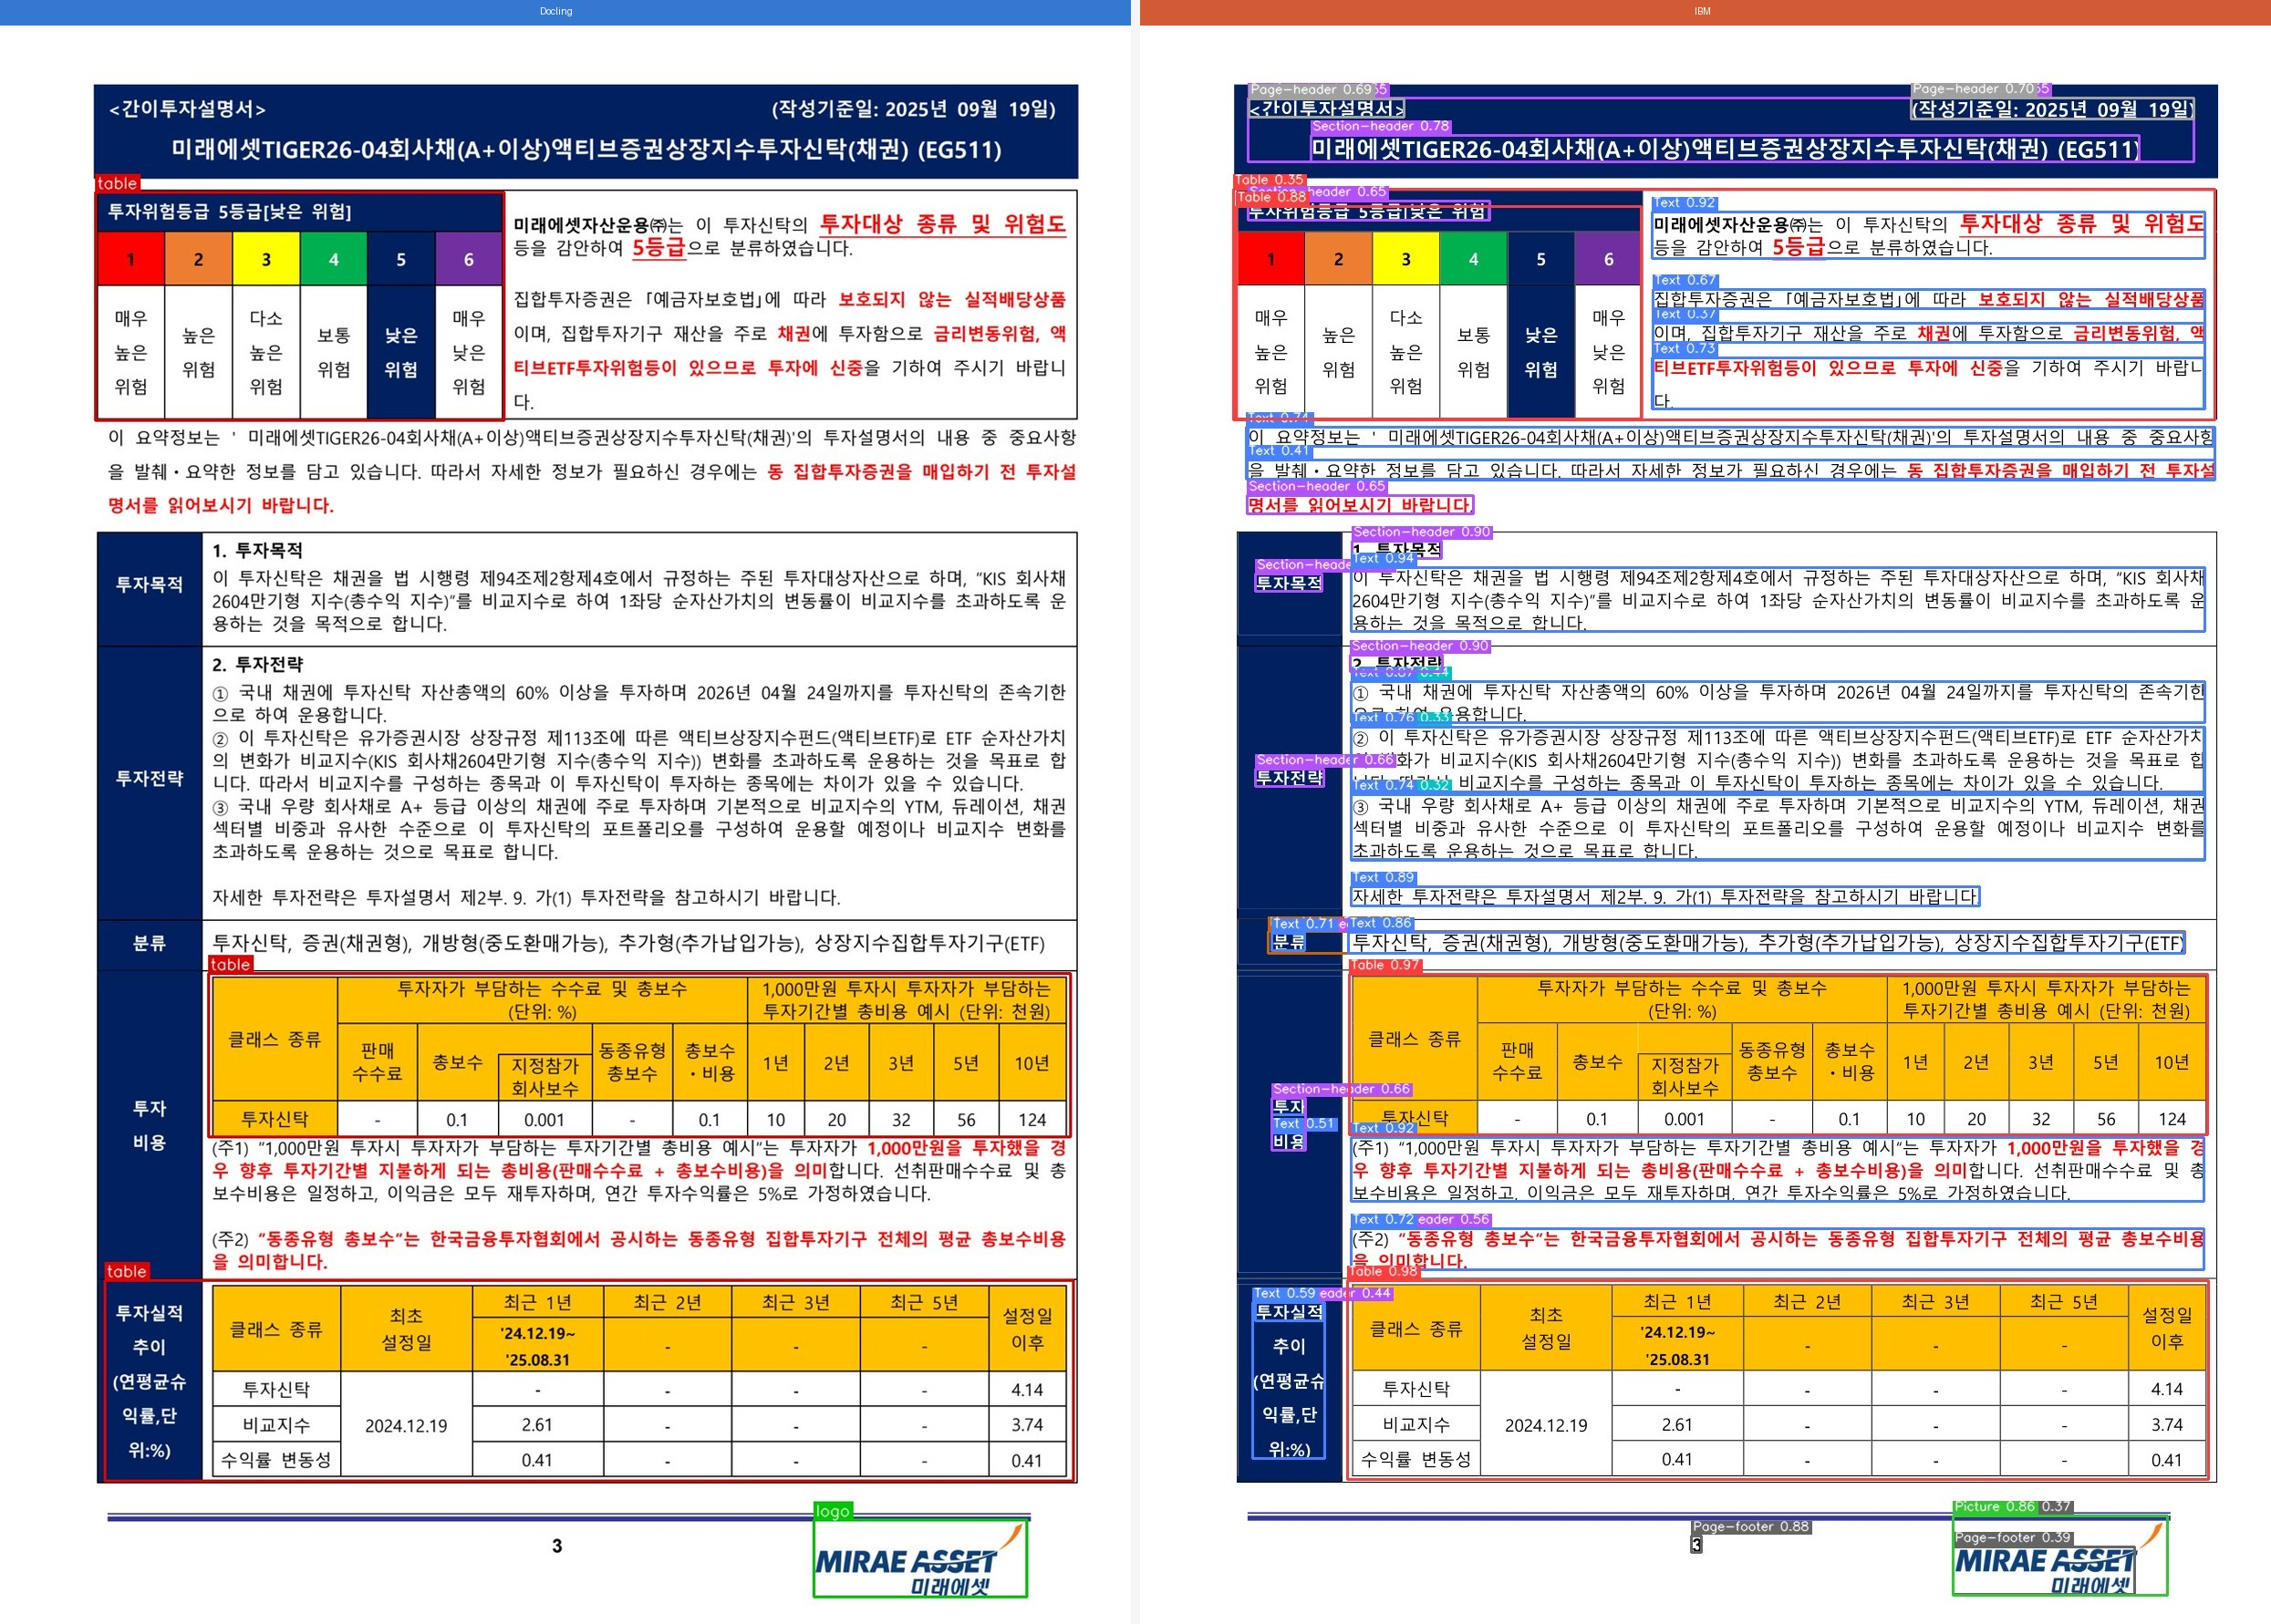

Page 2


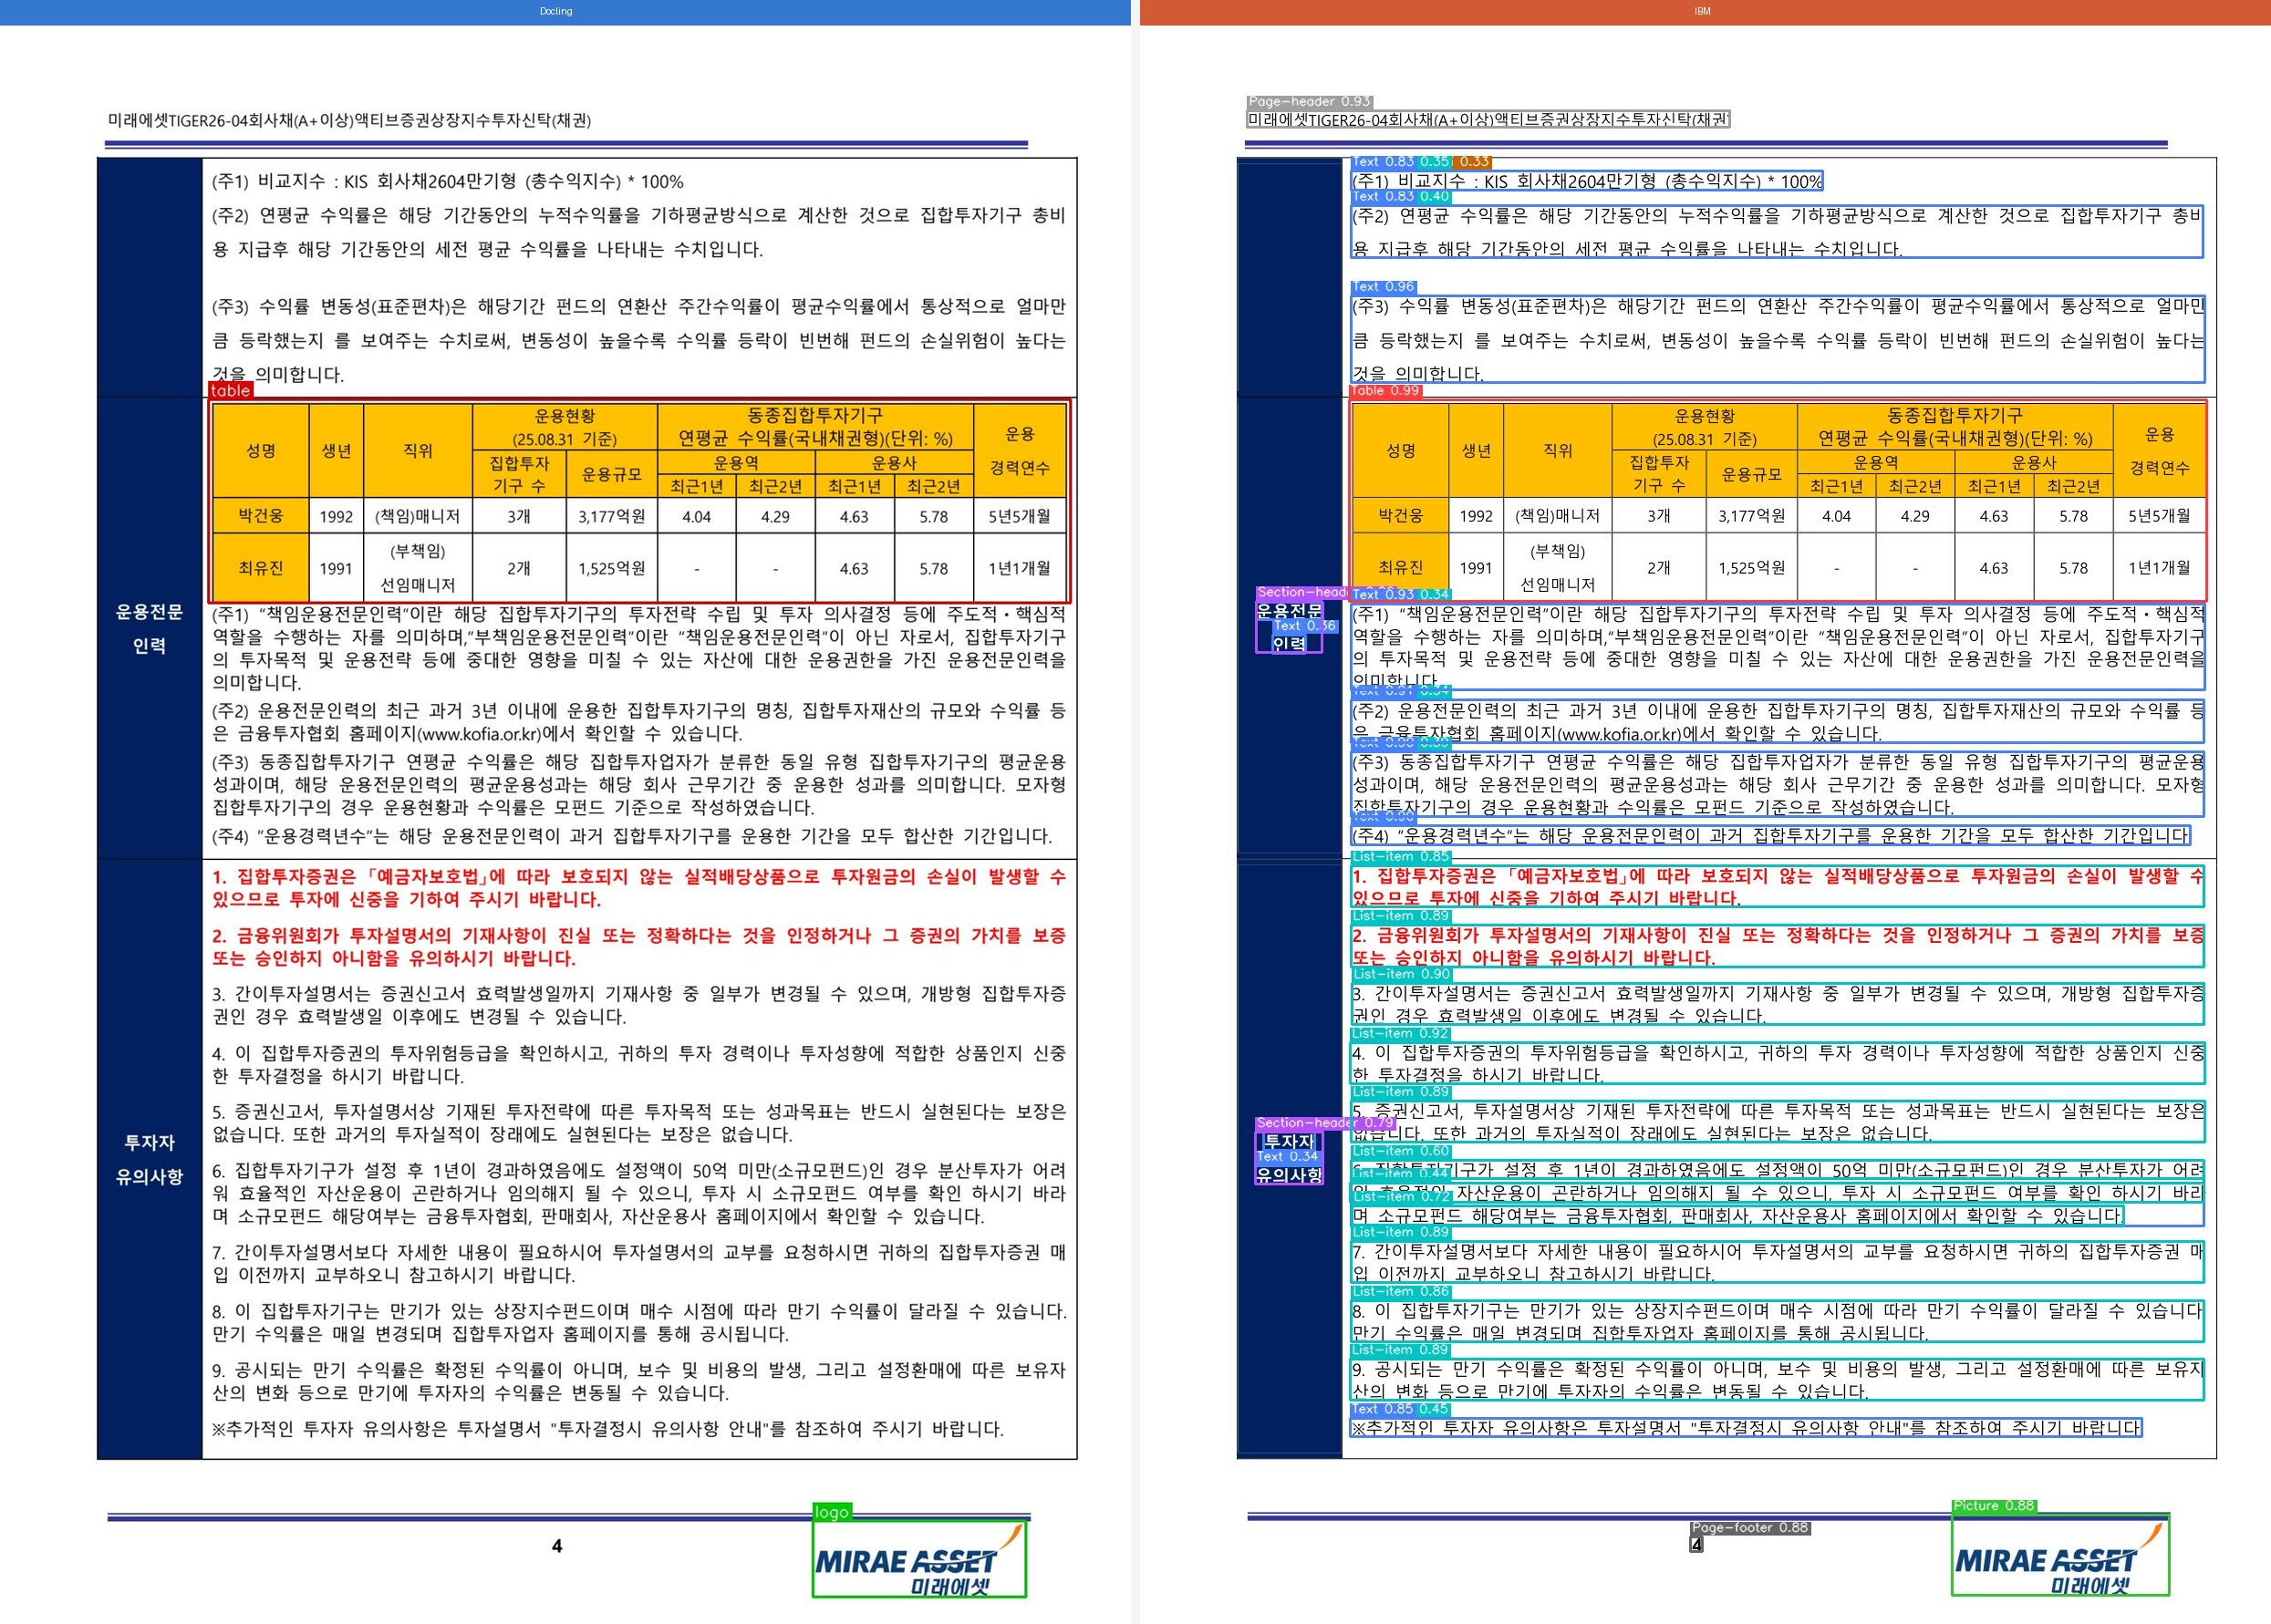

Page 3


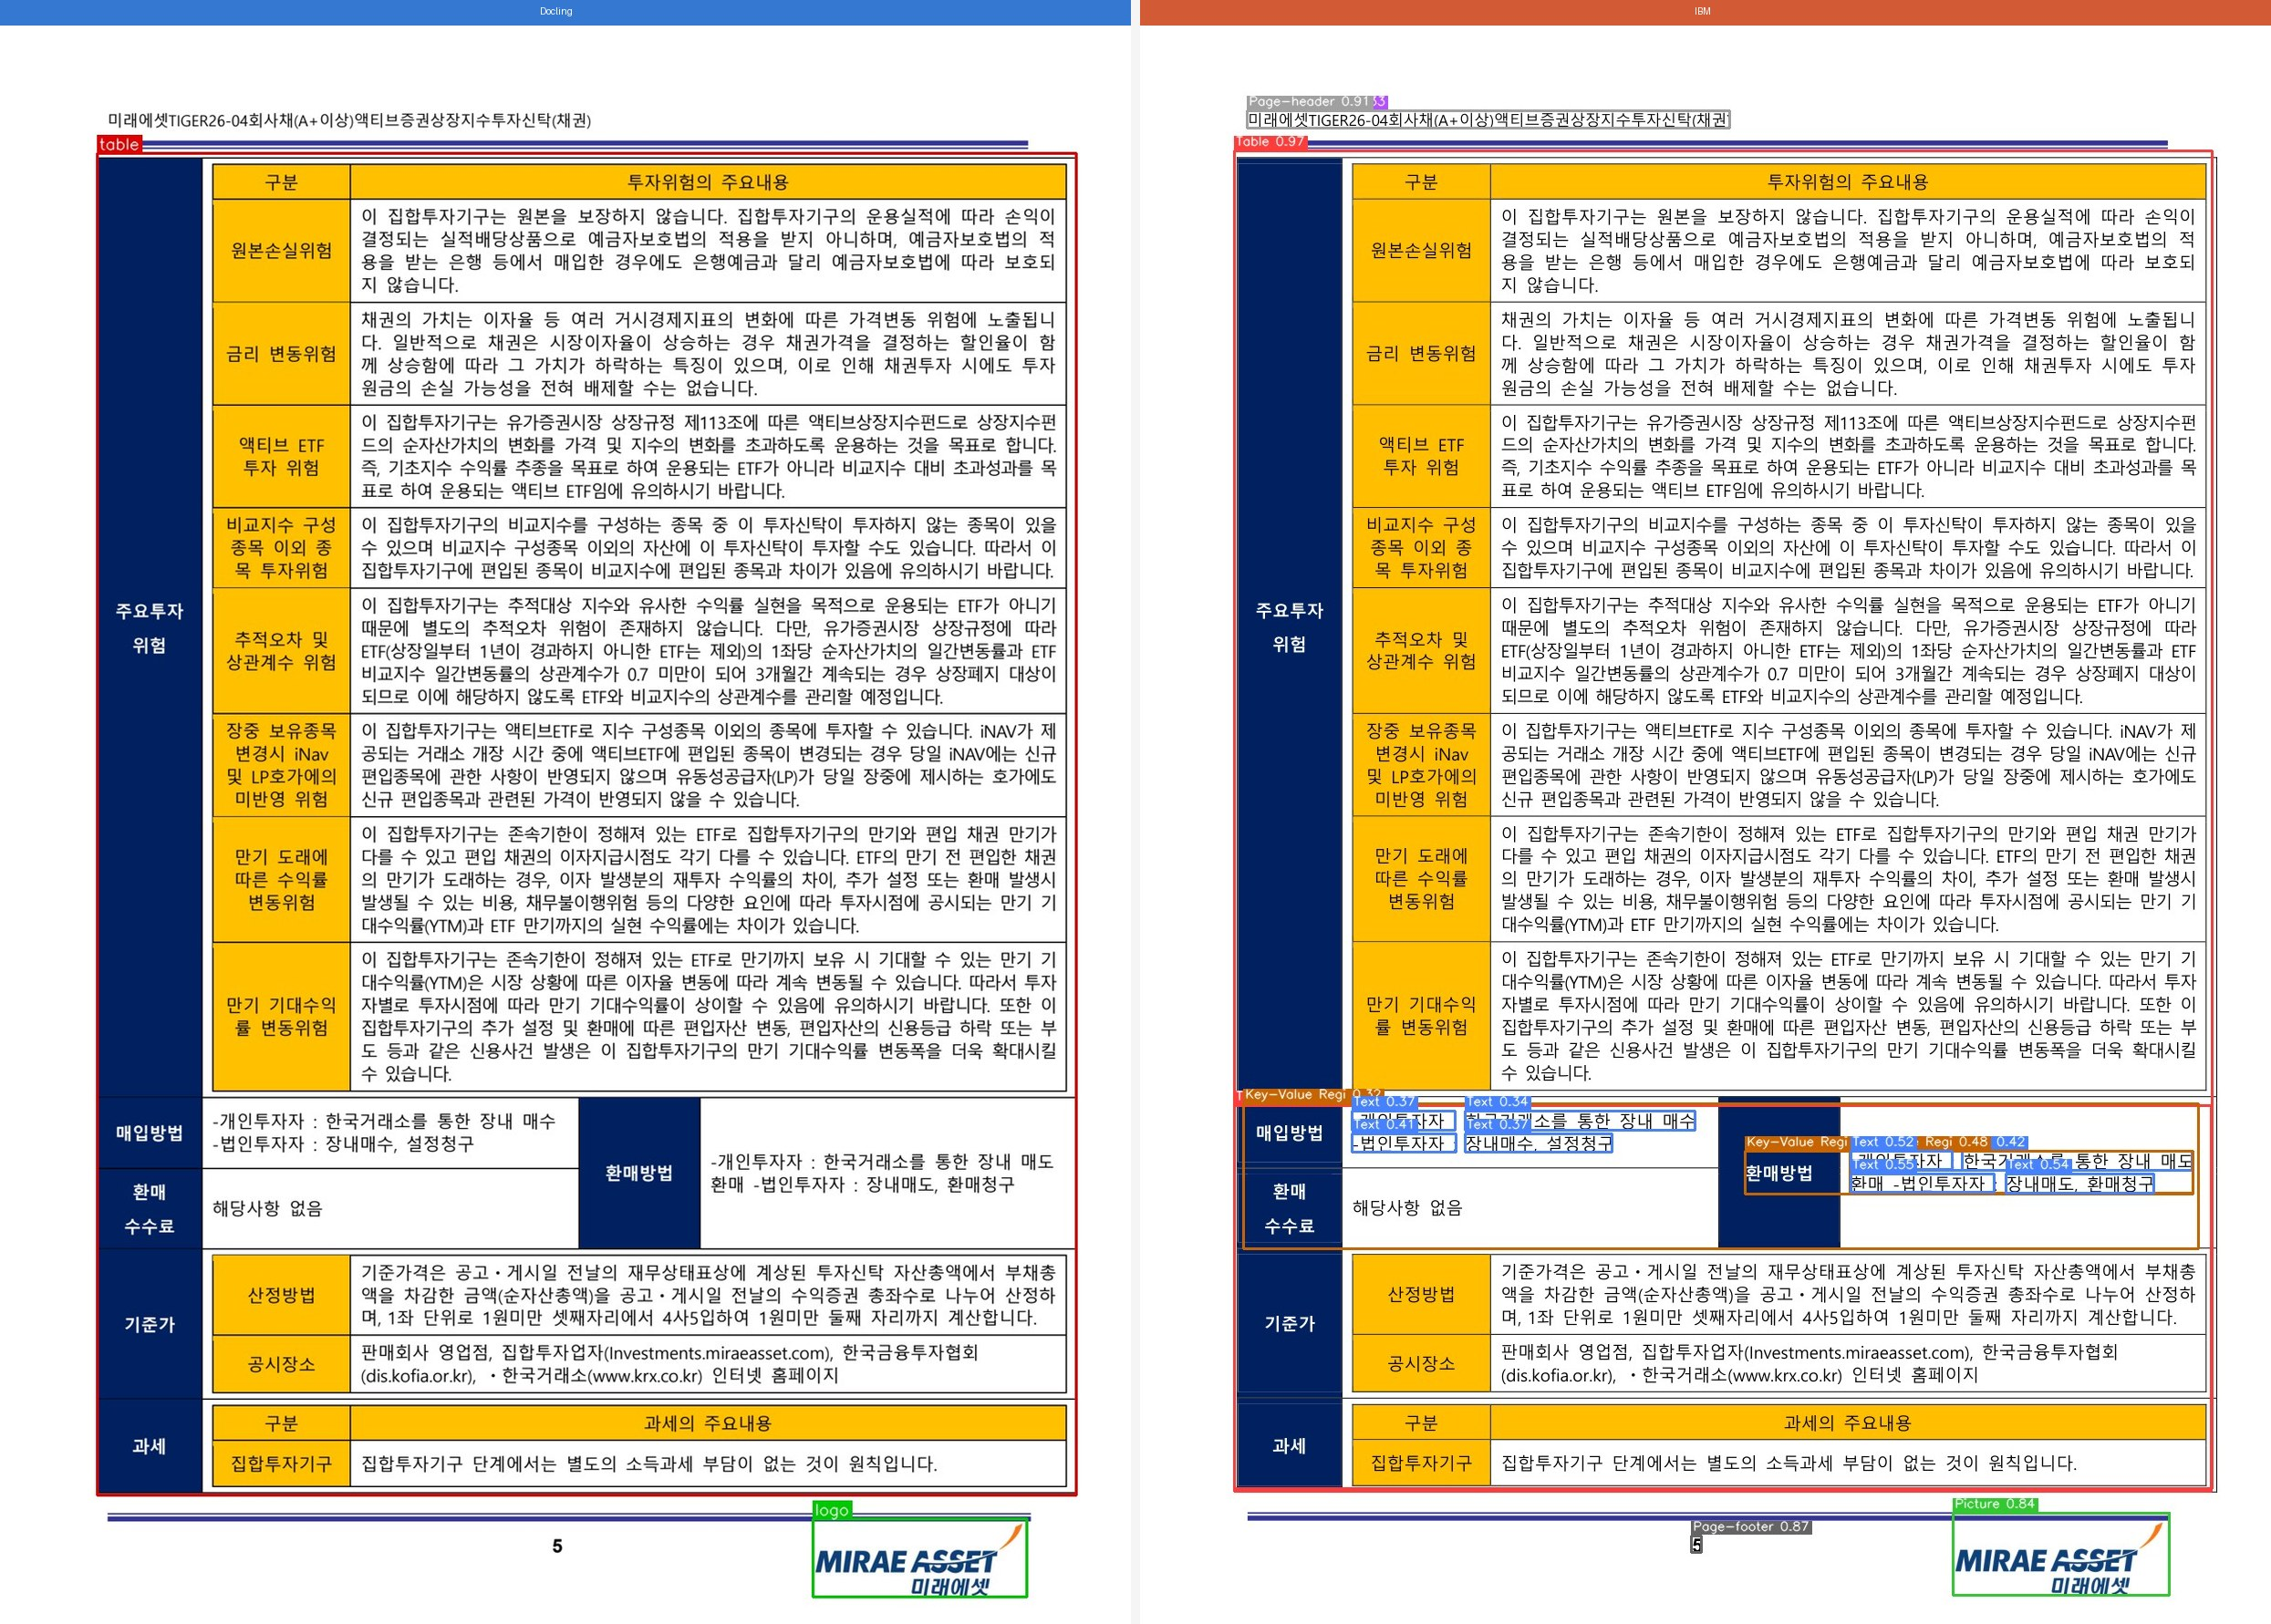

Page 4


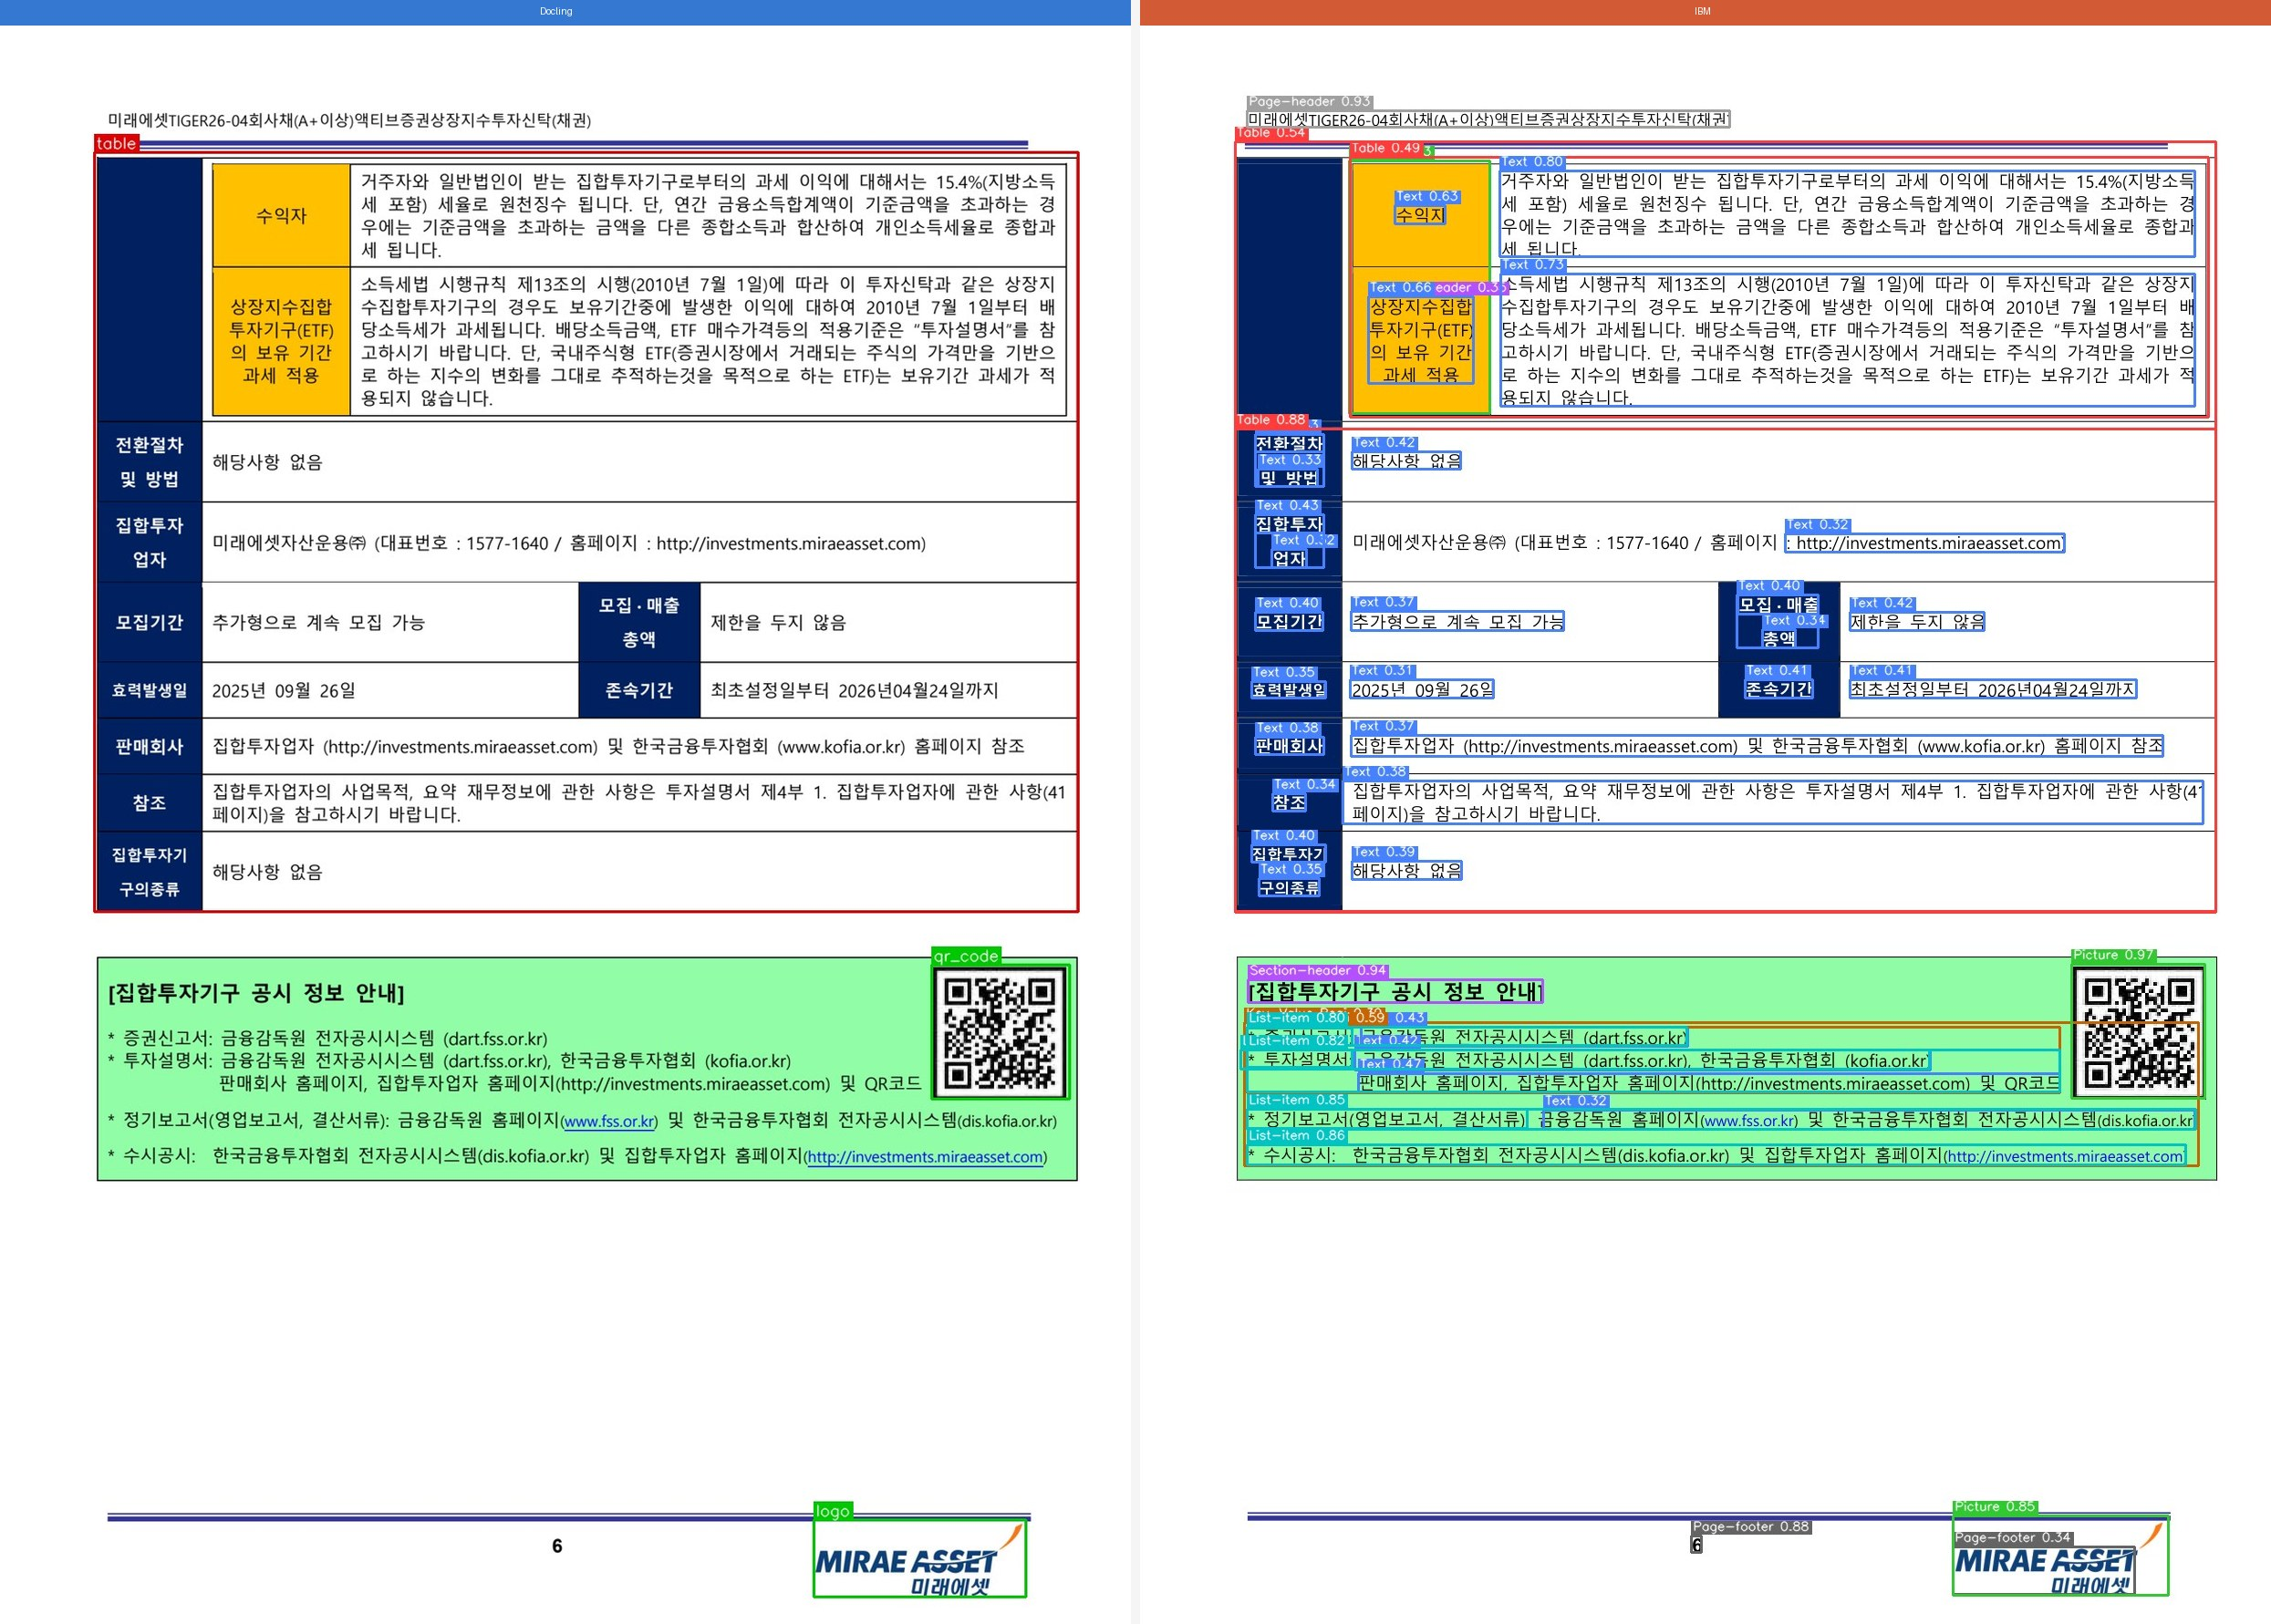


비교 이미지 저장 위치: /tmp/ocr_compare__8oqad4_/compare


In [55]:
import numpy as np
import cv2
from PIL import Image, ImageDraw

def _load_s3_image(uri: str) -> Image.Image | None:
    """S3 URI에서 이미지를 PIL로 로드."""
    try:
        bucket, key = s3.parse_s3_uri(uri)
        resp = s3._client.get_object(Bucket=bucket, Key=key)
        data = resp['Body'].read()
        arr = np.frombuffer(data, np.uint8)
        bgr = cv2.imdecode(arr, cv2.IMREAD_COLOR)
        return Image.fromarray(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
    except Exception as e:
        print(f"  이미지 로드 실패 ({uri}): {e}")
        return None


def _side_by_side(img_a: Image.Image, img_b: Image.Image,
                  label_a: str = "Docling", label_b: str = "IBM",
                  gap: int = 10) -> Image.Image:
    """두 이미지를 같은 높이로 맞춰 좌우로 합친다."""
    target_h = max(img_a.height, img_b.height)
    scale_a  = target_h / img_a.height
    scale_b  = target_h / img_b.height

    w_a = int(img_a.width  * scale_a)
    w_b = int(img_b.width  * scale_b)

    ra = img_a.resize((w_a, target_h), Image.LANCZOS)
    rb = img_b.resize((w_b, target_h), Image.LANCZOS)

    banner_h = 28
    total_w  = w_a + gap + w_b
    canvas   = Image.new("RGB", (total_w, target_h + banner_h), (245, 245, 245))

    draw = ImageDraw.Draw(canvas)
    draw.rectangle([0, 0, w_a - 1, banner_h - 1], fill=(52, 120, 210))
    draw.rectangle([w_a + gap, 0, total_w - 1, banner_h - 1], fill=(210, 90, 52))
    draw.text((w_a // 2 - len(label_a) * 4, 6),  label_a, fill="white")
    draw.text((w_a + gap + w_b // 2 - len(label_b) * 4, 6), label_b, fill="white")

    canvas.paste(ra, (0,         banner_h))
    canvas.paste(rb, (w_a + gap, banner_h))
    return canvas


# ── URI 목록 확인 ──────────────────────────────────────────────────────────────
if ('result_docling' not in dir() or not result_docling or
    'result_ibm'     not in dir() or not result_ibm):
    print("4번 섹션에서 두 모드를 모두 실행한 후 다시 실행하세요.")
else:
    uris_d = sorted(result_docling.get('bboxImagesUris') or [])
    uris_i = sorted(result_ibm.get('bboxImagesUris') or [])

    # URI가 실제로 다른지 검증
    print("Docling bbox URIs:")
    for u in uris_d:
        print(f"  {u}")
    print("IBM bbox URIs:")
    for u in uris_i:
        print(f"  {u}")

    if uris_d and uris_i and uris_d == uris_i:
        print("\n[경고] 두 URI 목록이 동일합니다. 4번 섹션을 다시 실행하세요.")
        print("  원인: 노트북을 이전 버전으로 실행하여 같은 S3 경로를 사용했을 가능성이 있습니다.")
    elif not uris_d and not uris_i:
        print("Bbox 이미지가 없습니다.")
    else:
        n_pages = max(len(uris_d), len(uris_i))
        print(f"\n페이지 수: Docling={len(uris_d)}, IBM={len(uris_i)}")
        print("  파란색 배너 = Docling  /  주황색 배너 = IBM\n")

        compare_dir = temp_dir / "compare"
        compare_dir.mkdir(exist_ok=True)

        for idx in range(n_pages):
            page_no = idx + 1
            print(f"{'='*70}")
            print(f"Page {page_no}")
            print(f"{'='*70}")

            img_d = _load_s3_image(uris_d[idx]) if idx < len(uris_d) else None
            img_i = _load_s3_image(uris_i[idx]) if idx < len(uris_i) else None

            if img_d and img_i:
                combined = _side_by_side(img_d, img_i)
                out_path = compare_dir / f"page{page_no:03d}_compare.jpg"
                combined.save(out_path, "JPEG", quality=88)
                display(IPImage(filename=str(out_path), width=1100))
            elif img_d:
                out_path = compare_dir / f"page{page_no:03d}_docling.jpg"
                img_d.save(out_path, "JPEG", quality=88)
                print("  (IBM 이미지 없음 — Docling만 표시)")
                display(IPImage(filename=str(out_path), width=700))
            elif img_i:
                out_path = compare_dir / f"page{page_no:03d}_ibm.jpg"
                img_i.save(out_path, "JPEG", quality=88)
                print("  (Docling 이미지 없음 — IBM만 표시)")
                display(IPImage(filename=str(out_path), width=700))

        print(f"\n비교 이미지 저장 위치: {compare_dir}")

### 5-3. 텍스트 마크다운 비교

In [ ]:
PREVIEW_CHARS = 2000  # 미리보기 문자 수

if ('result_docling' not in dir() or not result_docling or
    'result_ibm'     not in dir() or not result_ibm):
    print("4번 섹션에서 두 모드를 모두 실행한 후 다시 실행하세요.")
else:
    md_d = s3.read_markdown(result_docling['textMarkdownUri'])
    md_i = s3.read_markdown(result_ibm['textMarkdownUri'])

    print(f"{'='*70}")
    print(f"Docling 텍스트  —  {len(md_d):,} 문자")
    print(f"{'='*70}")
    display(Markdown(f"```\n{md_d[:PREVIEW_CHARS]}\n{'...(생략)' if len(md_d) > PREVIEW_CHARS else ''}\n```"))

    print(f"\n{'='*70}")
    print(f"IBM 텍스트 (PyMuPDF)  —  {len(md_i):,} 문자")
    print(f"{'='*70}")
    display(Markdown(f"```\n{md_i[:PREVIEW_CHARS]}\n{'...(생략)' if len(md_i) > PREVIEW_CHARS else ''}\n```"))

## 6. 개별 모드 단독 실행

위 섹션에서 비교하지 않고 특정 모드만 단독으로 실행하려면 아래 셀을 사용하세요.

In [ ]:
# 원하는 모드와 PDF 경로를 직접 지정하고 실행하세요.

SINGLE_INPUT_PDF    = INPUT_PDF if 'INPUT_PDF' in dir() and INPUT_PDF else "s3://bucket/input/sample.pdf"
SINGLE_OUTPUT       = OUTPUT_BASE
SINGLE_LAYOUT_MODEL = "ibm"       # "docling" 또는 "ibm"
SINGLE_TABLE_MODE   = "accurate"  # Docling 전용 (ibm 모드에서는 무시됨)
SINGLE_GENERATE_BBOX = True

# IBM 감도 조정: 1번 셀의 IBM_CONFIDENCE_THRESHOLD를 사용하거나 여기서 직접 덮어쓸 수 있음
# SINGLE_THRESHOLD = 0.15  # 주석 해제 시 이 값 사용
SINGLE_THRESHOLD = IBM_CONFIDENCE_THRESHOLD  # 기본: 1번 셀 설정값 사용

print(f"실행 설정")
print(f"  inputPath              : {SINGLE_INPUT_PDF}")
print(f"  outputPath             : {SINGLE_OUTPUT}")
print(f"  modelId                : {SINGLE_LAYOUT_MODEL}")
print(f"  tableMode              : {SINGLE_TABLE_MODE}  (Docling 전용)")
print(f"  bboxImages             : {SINGLE_GENERATE_BBOX}")
print(f"  ibmConfidenceThreshold : {SINGLE_THRESHOLD}  (IBM 전용)")
print()

t0 = time.time()
resp = requests.post(
    f"{API_BASE_URL}/ocr",
    json={
        "inputPath"            : SINGLE_INPUT_PDF,
        "outputPath"           : SINGLE_OUTPUT,
        "tableMode"            : SINGLE_TABLE_MODE,
        "generateBboxImages"   : SINGLE_GENERATE_BBOX,
        "modelId"              : SINGLE_LAYOUT_MODEL,
        "ibmConfidenceThreshold": SINGLE_THRESHOLD,
    },
    timeout=600,
)
elapsed = time.time() - t0

if resp.status_code == 200:
    result_single = resp.json()
    print(f"완료 — {elapsed:.1f}초")
    print(f"  textMarkdownUri : {result_single['textMarkdownUri']}")
    print(f"  stats           : {result_single['stats']}")
    if result_single.get('bboxImagesUris'):
        print(f"  bbox images     : {len(result_single['bboxImagesUris'])}개")
        for uri in result_single['bboxImagesUris']:
            print(f"    {uri}")
else:
    print(f"실패 ({resp.status_code}):")
    print(resp.text)

### 6-1. 단독 실행 결과 bbox 이미지 표시

In [ ]:
if 'result_single' not in dir() or not result_single:
    print("위 셀에서 단독 실행을 먼저 실행해주세요.")
elif not result_single.get('bboxImagesUris'):
    print("Bbox 이미지가 없습니다.")
else:
    uris = sorted(result_single['bboxImagesUris'])
    single_dir = temp_dir / "single"
    single_dir.mkdir(exist_ok=True)

    for idx, uri in enumerate(uris):
        page_no = idx + 1
        print(f"\n{'='*60}")
        print(f"Page {page_no}  [{SINGLE_LAYOUT_MODEL}]")
        print(f"{'='*60}")

        img = _load_s3_image(uri)
        if img:
            out_path = single_dir / f"page{page_no:03d}.jpg"
            img.save(out_path, "JPEG", quality=88)
            display(IPImage(filename=str(out_path), width=800))

## 7. IBM 레이블 색상 범례

In [ ]:
# IBM LayoutPredictor bbox 이미지에 사용된 색상 범례
LABEL_COLORS_RGB = {
    "Table"              : (255,  60,  60),
    "Table rotated"      : (255, 140,   0),
    "Picture / Figure"   : ( 50, 200,  50),
    "Text"               : ( 70, 130, 255),
    "Title"              : (160,   0, 220),
    "Section-header"     : (180,  80, 255),
    "List-item"          : (195, 195,   0),
    "Formula"            : (255,  20, 147),
    "Code"               : (128, 128,   0),
    "Page-header"        : (160, 160, 160),
    "Page-footer"        : (100, 100, 100),
    "Caption"            : (255, 200,   0),
    "Footnote"           : (160,  82,  45),
    "Key-Value Region"   : (200, 100,   0),
}

SWATCH_W, SWATCH_H = 24, 18
PAD = 4
ROW_H = SWATCH_H + PAD * 2
COLS  = 2
items = list(LABEL_COLORS_RGB.items())
rows  = (len(items) + COLS - 1) // COLS
COL_W = 260

canvas = Image.new("RGB", (COL_W * COLS + PAD, ROW_H * rows + PAD), (250, 250, 250))
draw   = ImageDraw.Draw(canvas)

for i, (label, color) in enumerate(items):
    col = i % COLS
    row = i // COLS
    x   = PAD + col * COL_W
    y   = PAD + row * ROW_H
    draw.rectangle([x, y, x + SWATCH_W, y + SWATCH_H], fill=color)
    draw.text((x + SWATCH_W + 6, y + 2), label, fill=(30, 30, 30))

legend_path = temp_dir / "ibm_legend.png"
canvas.save(legend_path)

print("IBM LayoutPredictor 레이블 색상 범례")
display(IPImage(filename=str(legend_path)))

## 요약

| 섹션 | 내용 |
|------|------|
| 1 | 라이브러리 & 설정 |
| 2 | API Health Check |
| 3 | S3 파일 브라우저로 PDF 선택 |
| 4-1 | Docling OCR 실행 (`modelId: "docling"`) |
| 4-2 | IBM OCR 실행 (`modelId: "ibm"`) |
| 5-1 | 처리 시간 / 감지 통계 비교 |
| 5-2 | Bbox 이미지 좌우 비교 (페이지별) |
| 5-3 | 텍스트 마크다운 내용 비교 |
| 6 | 특정 모드 단독 실행 |
| 7 | IBM 레이블 색상 범례 |

### API 파라미터
```json
POST /ocr
{
  "inputPath"       : "s3://bucket/input.pdf",
  "outputPath"      : "s3://bucket/output/",
  "modelId"         : "docling",   // 또는 "ibm"
  "tableMode"       : "accurate",  // Docling 전용
  "generateBboxImages": true,
  "useAccelerator"  : false        // Docling 전용
}
```